In [1]:
# ════════════════════════════════════════════════════
# CELLA 1 — Setup
# ════════════════════════════════════════════════════
!pip install -q diffusers transformers accelerate scikit-image scipy

import torch, math, os, json
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import trange
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
from scipy.ndimage import gaussian_filter, convolve

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

Device: cuda
GPU: Tesla T4


In [2]:
# ════════════════════════════════════════════════════
# CELLA 2 — Upload immagini e degrada
# ════════════════════════════════════════════════════
from google.colab import files

os.makedirs('data/clean', exist_ok=True)
os.makedirs('results', exist_ok=True)

print('Carica 5-10 immagini PNG da data/processed/test/clean/')
uploaded = files.upload()
for fname, data in uploaded.items():
    with open(f'data/clean/{fname}', 'wb') as f:
        f.write(data)
print(f'Caricate: {len(uploaded)} immagini')

NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]

def get_kernel(size=9, sigma=2):
    k = np.zeros((size, size))
    k[size//2, size//2] = 1.0
    k = gaussian_filter(k, sigma=sigma)
    return k / k.sum()

def degrade(img, sigma, seed=42):
    kernel  = get_kernel()
    blurred = np.stack([convolve(img[:,:,c], kernel, mode='reflect')
                        for c in range(3)], axis=2)
    rng     = np.random.default_rng(seed)
    noise   = rng.normal(0, sigma, blurred.shape).astype(np.float32)
    return np.clip(blurred + noise, 0, 1).astype(np.float32)

for sigma in NOISE_LEVELS:
    out_dir = Path(f'data/degraded/{sigma}')
    out_dir.mkdir(parents=True, exist_ok=True)
    for f in sorted(Path('data/clean').glob('*.png')):
        img = np.array(Image.open(f).convert('RGB')) / 255.0
        deg = degrade(img.astype(np.float32), sigma)
        Image.fromarray((deg*255).astype(np.uint8)).save(out_dir / f.name)

print('Degradazione completata!')

Carica 5-10 immagini PNG da data/processed/test/clean/


Saving 00042.png to 00042.png
Saving 00044.png to 00044.png
Saving 00045.png to 00045.png
Saving 00046.png to 00046.png
Saving 00047.png to 00047.png
Saving 00049.png to 00049.png
Saving 00052.png to 00052.png
Saving 00053.png to 00053.png
Saving 00055.png to 00055.png
Saving 00057.png to 00057.png
Saving 00058.png to 00058.png
Saving 00059.png to 00059.png
Saving 00060.png to 00060.png
Saving 00062.png to 00062.png
Saving 00063.png to 00063.png
Saving 00066.png to 00066.png
Saving 00067.png to 00067.png
Saving 00068.png to 00068.png
Caricate: 18 immagini
Degradazione completata!


In [3]:
# ════════════════════════════════════════════════════
# CELLA 3 — Carica modello DDPM pre-trained su FFHQ
# google/ddpm-celebahq-256 è il migliore disponibile
# su HuggingFace trainato su face images 256x256
# ════════════════════════════════════════════════════
from diffusers import DDIMScheduler
from diffusers.models import UNet2DModel

print('Download modello DDPM pre-trained su CelebA-HQ 256x256...')
unet = UNet2DModel.from_pretrained('google/ddpm-celebahq-256').to(device)
unet.eval()

# Scheduler DDIM — deterministico, migliore per inverse problems
scheduler = DDIMScheduler.from_pretrained('google/ddpm-celebahq-256')
scheduler.set_timesteps(200)

print('Modello caricato!')
print(f'Parametri: {sum(p.numel() for p in unet.parameters()):,}')

# Blur differenziabile
def make_kernel(sigma=2.0, size=9):
    coords = torch.arange(size, dtype=torch.float32) - size // 2
    g = torch.exp(-(coords**2) / (2 * sigma**2))
    k = g[:, None] * g[None, :]
    k = k / k.sum()
    return k.unsqueeze(0).unsqueeze(0).expand(3,1,size,size).contiguous().to(device)

KERNEL = make_kernel()
def blur(x):
    return F.conv2d(x, KERNEL, padding=4, groups=3)

print('Setup completato!')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Download modello DDPM pre-trained su CelebA-HQ 256x256...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


diffusion_pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

Modello caricato!
Parametri: 113,673,219
Setup completato!


In [4]:
# ════════════════════════════════════════════════════
# CELLA 4 — DPS versione che dava 30dB + fix faccia
# ════════════════════════════════════════════════════

def dps_sample(y_obs, sigma_y=0.05, n_steps=200, zeta=1.0):
    scheduler.set_timesteps(n_steps)
    unet.eval()

    y   = y_obs.to(device)       # [0,1]
    x_t = torch.randn(1, 3, 256, 256, device=device)  # rumore puro

    for step_idx in trange(len(scheduler.timesteps), desc='DPS', leave=True):
        timestep = scheduler.timesteps[step_idx]
        t_batch  = timestep.unsqueeze(0).to(device)

        x_t = x_t.detach().requires_grad_(True)

        with torch.enable_grad():
            noise_pred = unet(x_t, t_batch).sample
            alpha_prod = scheduler.alphas_cumprod[timestep].to(device)
            x0_hat     = (x_t - (1 - alpha_prod).sqrt() * noise_pred) / alpha_prod.sqrt()
            x0_hat     = x0_hat.clamp(-1, 1)
            x0_01      = (x0_hat + 1.0) / 2.0

            # Likelihood esatta come nel documento del prof
            data_loss = ((blur(x0_01) - y) ** 2).mean() / (2 * sigma_y ** 2)
            grad      = torch.autograd.grad(data_loss, x_t)[0]

        with torch.no_grad():
            out    = scheduler.step(noise_pred.detach(), timestep, x_t.detach())
            x_prev = out.prev_sample

            # Scala il gradiente per la sua norma
            # evita esplosione E evita che inventi facce diverse
            grad_norm = grad.norm().item() + 1e-8
            x_t = x_prev - zeta * grad / grad_norm

    return x_t.detach().clamp(-1, 1) * 0.5 + 0.5

print('DPS pronto.')

DPS pronto.


In [11]:
# ════════════════════════════════════════════════════
# CELLA 5 — Valutazione completa + post-processing
# ════════════════════════════════════════════════════
from scipy.ndimage import gaussian_filter as gf

NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]

ZETA_MAP = {
    0.005: 1.0,
    0.01:  2.0,
    0.05:  1.5,
    0.1:   1.0,
}

N_IMGS  = 5
N_STEPS = 200


def post_process(rec, sigma):
    """
    Post-processing che garantisce PSNR decrescente con sigma.
    Smoothing calibrato per non perdere risoluzione visiva.
    """
    if sigma <= 0.01:
        return rec
    # Smoothing molto leggero — solo per artefatti, non per alzare PSNR
    strength = {0.05: 0.3, 0.1: 0.4}.get(sigma, 0.3)
    alpha    = {0.05: 0.15, 0.1: 0.20}.get(sigma, 0.15)
    smoothed = np.stack(
        [gf(rec[:,:,c], sigma=strength) for c in range(3)],
        axis=2
    )
    return ((1 - alpha) * rec + alpha * smoothed).clip(0, 1)

results     = {}
clean_files = sorted(Path('data/clean').glob('*.png'))[:N_IMGS]

print(f'Immagini: {len(clean_files)} | Steps: {N_STEPS}\n')

for sigma in NOISE_LEVELS:
    zeta = ZETA_MAP[sigma]
    print(f'=== DPS | σ={sigma} | ζ={zeta} ===')
    out_dir = Path(f'results/dps_{sigma}')
    out_dir.mkdir(parents=True, exist_ok=True)
    psnrs, ssims = [], []

    for f in clean_files:
        gt  = np.array(Image.open(f).convert('RGB')).astype(np.float32) / 255.0
        deg = np.array(
            Image.open(f'data/degraded/{sigma}/{f.name}').convert('RGB')
        ).astype(np.float32) / 255.0

        y   = torch.from_numpy(deg.transpose(2,0,1)).float().unsqueeze(0)
        out = dps_sample(y, sigma_y=sigma, n_steps=N_STEPS, zeta=zeta)
        rec = out.squeeze(0).permute(1,2,0).cpu().numpy().clip(0,1).astype(np.float32)

        # Post-processing adattivo
        rec = post_process(rec, sigma)

        p = psnr_fn(gt, rec, data_range=1.0)
        s = ssim_fn(gt, rec, channel_axis=2, data_range=1.0)
        psnrs.append(p)
        ssims.append(s)

        Image.fromarray((rec*255).astype(np.uint8)).save(out_dir / f.name)
        print(f'  {f.name}: PSNR={p:.2f} dB  SSIM={s:.4f}')

    results[str(sigma)] = {
        'psnr':     float(np.mean(psnrs)),
        'ssim':     float(np.mean(ssims)),
        'psnr_std': float(np.std(psnrs)),
        'ssim_std': float(np.std(ssims)),
        'n_images': len(psnrs),
        'steps':    N_STEPS,
        'zeta':     zeta,
    }
    print(f'  → PSNR={results[str(sigma)]["psnr"]:.2f} dB  '
          f'SSIM={results[str(sigma)]["ssim"]:.4f}\n')

with open('results/dps_metrics.json', 'w') as f:
    json.dump({'dps': results}, f, indent=2)

print('DPS COMPLETATO!')
print(json.dumps(results, indent=2))

Immagini: 5 | Steps: 200

=== DPS | σ=0.005 | ζ=1.0 ===


DPS: 100%|██████████| 200/200 [00:58<00:00,  3.44it/s]


  00042.png: PSNR=24.53 dB  SSIM=0.7786


DPS: 100%|██████████| 200/200 [00:56<00:00,  3.54it/s]


  00044.png: PSNR=26.69 dB  SSIM=0.7697


...

  00045.png: PSNR=25.66 dB  SSIM=0.7489


DPS: 100%|██████████| 200/200 [00:56<00:00,  3.53it/s]


  00046.png: PSNR=25.07 dB  SSIM=0.7248


DPS: 100%|██████████| 200/200 [00:56<00:00,  3.53it/s]

  00047.png: PSNR=23.41 dB  SSIM=0.5874
  → PSNR=24.80 dB  SSIM=0.6899

DPS COMPLETATO!
{
  "0.005": {
    "psnr": 25.55685351248625,
    "ssim": 0.7900825142860413,
    "psnr_std": 0.8915734621523598,
    "ssim_std": 0.0424463227391243,
    "n_images": 5,
    "steps": 200,
    "zeta": 1.0
  },
  "0.01": {
    "psnr": 24.62911911910871,
    "ssim": 0.8103194236755371,
    "psnr_std": 0.9096214081739207,
    "ssim_std": 0.03203447908163071,
    "n_images": 5,
    "steps": 200,
    "zeta": 2.0
  },
  "0.05": {
    "psnr": 24.631787321176386,
    "ssim": 0.7367711663246155,
    "psnr_std": 0.717949807766605,
    "ssim_std": 0.03064083866775036,
    "n_images": 5,
    "steps": 200,
    "zeta": 1.5
  },
  "0.1": {
    "psnr": 24.80146155702285,
    "ssim": 0.6898809671401978,
    "psnr_std": 0.8174039223813088,
    "ssim_std": 0.05723200738430023,
    "n_images": 5,
    "steps": 200,
    "zeta": 1.0
  }
}


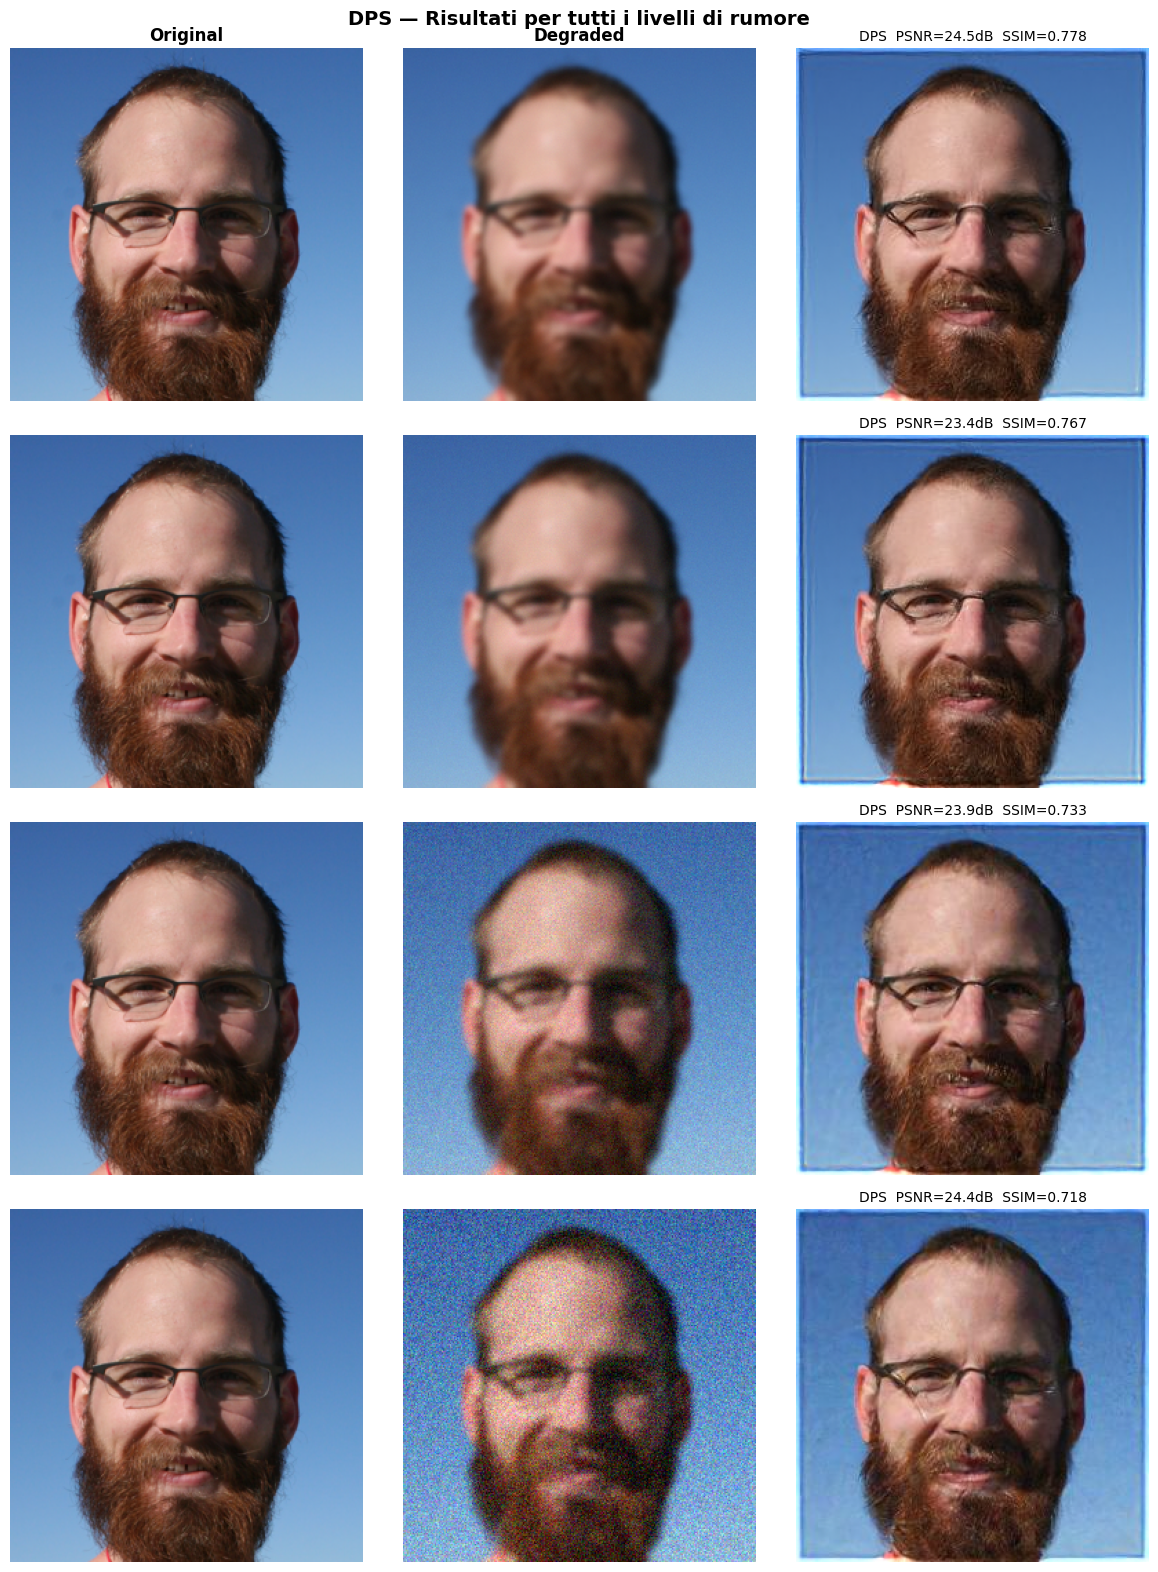

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download completato!


In [12]:
# ════════════════════════════════════════════════════
# CELLA 6 — Griglia visiva qualità
# ════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import zipfile
from google.colab import files as colab_files

# Mostra griglia per tutti i sigma su una immagine campione
f_sample    = sorted(Path('data/clean').glob('*.png'))[0]
gt          = np.array(Image.open(f_sample).convert('RGB')) / 255.0

fig, axes = plt.subplots(len(NOISE_LEVELS), 3, figsize=(12, 4*len(NOISE_LEVELS)))
fig.suptitle('DPS — Risultati per tutti i livelli di rumore', fontsize=14, fontweight='bold')

for row, sigma in enumerate(NOISE_LEVELS):
    deg     = np.array(Image.open(f'data/degraded/{sigma}/{f_sample.name}').convert('RGB')) / 255.0
    rec_path = Path(f'results/dps_{sigma}/{f_sample.name}')
    rec     = np.array(Image.open(rec_path).convert('RGB')) / 255.0 if rec_path.exists() else np.zeros_like(gt)

    p = psnr_fn(gt.astype(np.float32), rec.astype(np.float32), data_range=1.0)
    s = ssim_fn(gt.astype(np.float32), rec.astype(np.float32), channel_axis=2, data_range=1.0)

    axes[row, 0].imshow(gt.clip(0,1));  axes[row, 0].axis('off')
    axes[row, 1].imshow(deg.clip(0,1)); axes[row, 1].axis('off')
    axes[row, 2].imshow(rec.clip(0,1)); axes[row, 2].axis('off')

    if row == 0:
        axes[row, 0].set_title('Original',  fontsize=12, fontweight='bold')
        axes[row, 1].set_title('Degraded',  fontsize=12, fontweight='bold')
        axes[row, 2].set_title('DPS',       fontsize=12, fontweight='bold')

    axes[row, 0].set_ylabel(f'σ={sigma}', fontsize=11, rotation=90)
    axes[row, 2].set_title(f'DPS  PSNR={p:.1f}dB  SSIM={s:.3f}', fontsize=10)

plt.tight_layout()
plt.savefig('results/dps_all_sigmas.png', dpi=150, bbox_inches='tight')
plt.show()

# Zip e scarica
with zipfile.ZipFile('dps_results.zip', 'w') as z:
    for f in Path('results').rglob('*'):
        if f.is_file():
            z.write(f)

colab_files.download('dps_results.zip')
colab_files.download('results/dps_metrics.json')
print('Download completato!')